# Testing Decoding: `decode_sequence_peaks` vs `decode_sequence_online`

One single sequence ($L=8$ patterns, $N=50$ neurons), simulated once, then decoded
two different ways from the *same* trajectory:

- **`decode_sequence_peaks`**: offline/batch. Looks at each pattern's own overlap
  trace independently and asks "does this pattern have any peak that clears
  `tolerance`?" -- a pattern can register even if it was never the single
  best-matching pattern at that instant.
- **`decode_sequence_online`**: streaming, winner-take-all. A pattern only gets
  recorded if it becomes the outright `argmax` *and* beats the current leader by
  more than `margin` -- stricter, and (as found earlier) tends to report an
  equal-or-lower retrieval count than the peaks-based decoder on the same trace.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np

import kuramoto_library2 as krm

import matplotlib.pyplot as plt

In [ ]:
CONFIG = dict(
    dt=0.02,  # integration timestep for the dynamical evolution
    T=50.0,  # total simulation time
    frequency_std=0.03,  # heterogeneity in intrinsic frequencies, adding disorder to retrieval dynamics
    phase_noise=0.01,  # stochastic phase perturbations during evolution (SDE mode only)
    d=3,  # order (polynomial degree) of the high-order Kuramoto / dense associative memory coupling
    corruption_rate=0.2,  # fraction of neurons flipped when mutating each next pattern
    tolerance=0.4,  # threshold for determining whether a pattern is successfully retrieved based on overlap peak
    mode="ode",  # 'ode' (deterministic Forward Euler) or 'sde' (Euler-Maruyama with phase noise)
)

MIN_DISTANCE = 1  # for decode_sequence_offline
STICKY_MARGIN = 0.01  # for decode_sequence_online

N = 50  # network size
L = 8  # sequence length (total patterns, including the base)
seed = 10


SyntaxError: invalid syntax (3668277783.py, line 15)

## Generate the sequence and simulate once

In [3]:
net = krm.KuramotoNetwork(N=N, seed=seed, **CONFIG)
A = net.generate_sequence(name="A", seq_len=L - 1, corruption_rate=CONFIG["corruption_rate"], seed=seed)
print(A)

result = net.simulate(A)

<Sequence 'A' | <VectorSequence [Pre-allocated] | Length: 8, Dim: 50>>


## Plot the overlap trace

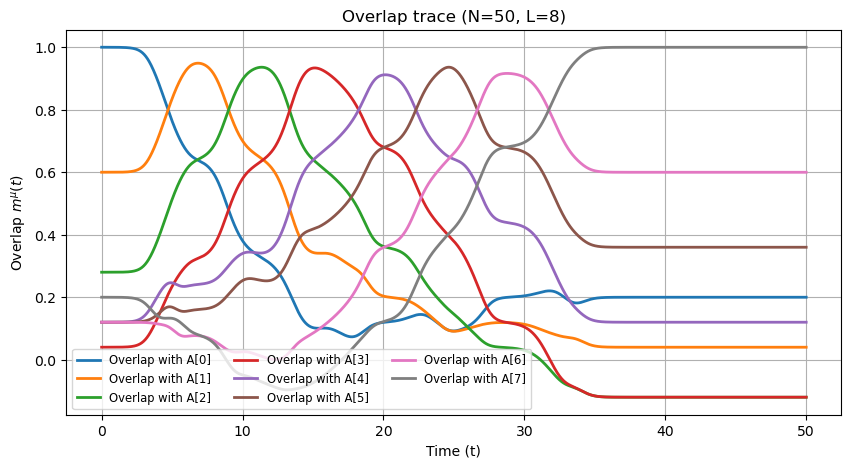

In [4]:
net.plot(result, A, title=f"Overlap trace (N={N}, L={L})")

## Decode: `decode_sequence_peaks`

In [ ]:
retrieved_peaks = net.decode_sequence_peaks(result, A, min_distance=MIN_DISTANCE)
fail_peaks = net.compare_to_stored_sequence(retrieved_peaks, A)

print("retrieved:", retrieved_peaks)
print("expected: ", A.labels())
print(f"fail_step = {fail_peaks}/{L}  (strict-decode fraction = {fail_peaks/L:.2f})")

retrieved: [('A', 0), ('A', 1), ('A', 2), ('A', 3), ('A', 4), ('A', 5), ('A', 6), ('A', 7)]
expected:  [('A', 0), ('A', 1), ('A', 2), ('A', 3), ('A', 4), ('A', 5), ('A', 6), ('A', 7)]
fail_step = 8/8  (strict-decode fraction = 1.00)


## Decode: `decode_sequence_online`

In [ ]:
retrieved_online = net.decode_sequence_online(result, A, margin=STICKY_MARGIN)
fail_online = net.compare_to_stored_sequence(retrieved_online, A)

print("retrieved:", retrieved_online)
print("expected: ", A.labels())
print(f"fail_step = {fail_online}/{L}  (strict-decode fraction = {fail_online/L:.2f})")

retrieved: [('A', 0), ('A', 1), ('A', 2), ('A', 3), ('A', 4), ('A', 5), ('A', 6), ('A', 7)]
expected:  [('A', 0), ('A', 1), ('A', 2), ('A', 3), ('A', 4), ('A', 5), ('A', 6), ('A', 7)]
fail_step = 8/8  (strict-decode fraction = 1.00)
